# Note d'Étape 2 — GTT × ENSAE Paris
## Prédiction des Temps d'Arrivée Maritimes — Océan Indien

**Partenaire industriel :** GTT (Gaztransport & Technigaz)  
**Données :** 13,7 millions de points AIS — période 2012–2025  
**Grille :** 0,5° × 0,5° — 7 zones géographiques

---
1. Configuration & Imports  
2. Chargement et Nettoyage  
3. Vitesse SOG  
4. Accélération  
5. Graphe de popularité & Heatmaps  
6. Modèle ETA Monte Carlo  
7. Séries temporelles — STL + ARMA  
8. Perspectives

## 0. Imports et Configuration

In [1]:
import subprocess, sys
for pkg in ["statsmodels", "seaborn"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg,
                               "--quiet", "--break-system-packages"])
print("Packages OK")

Packages OK


In [2]:
from __future__ import annotations
import os, heapq, itertools, warnings
from typing import Dict, Tuple, List
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import norm, lognorm, gamma, weibull_min
warnings.filterwarnings("ignore")

try:
    from statsmodels.tsa.stattools import adfuller, acf, pacf
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tsa.seasonal import STL
    STATSMODELS_OK = True
except ImportError:
    STATSMODELS_OK = False
    print("statsmodels absent — sections ARMA desactivees")

# ── Style graphique sobre (fond blanc, matplotlib standard) ───────
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.edgecolor":    "#333333",
    "axes.labelcolor":   "#333333",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "text.color":        "#333333",
    "xtick.color":       "#333333",
    "ytick.color":       "#333333",
    "grid.color":        "#cccccc",
    "grid.alpha":        0.5,
    "font.family":       "sans-serif",
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.labelsize":    11,
    "legend.frameon":    True,
    "legend.framealpha": 0.9,
    "figure.dpi":        110,
    "savefig.dpi":       150,
    "savefig.bbox":      "tight",
    "savefig.facecolor": "white",
})

# Palette de couleurs sobre (matplotlib standard + quelques accents)
C1 = "#1f77b4"   # bleu standard matplotlib
C2 = "#ff7f0e"   # orange standard matplotlib
C3 = "#2ca02c"   # vert
C4 = "#d62728"   # rouge
C5 = "#9467bd"   # violet
C6 = "#8c564b"   # marron
C7 = "#e377c2"   # rose

ZONE_PALETTE = [C1, C2, C3, C4, C5, C6, C7]

print("Imports et style OK")

Imports et style OK


In [3]:
# ── Configuration globale ────────────────────────────────────────
DATA_PATH   = "/home/onyxia/work/data/data_indian_ocean.feather"
SAMPLE_FRAC = 0.10        # 10% en dev → 1.0 en prod

SOG_MIN     = 1.0
SOG_MAX     = 30.0
NAV_OK      = {0, 8}
DATE_MIN    = "2012-01-01"

CELL_DEG    = 0.5
ALPHA       = 0.1
N_MC        = 10_000
MIN_OBS     = 30
HS_SEUIL    = 2.5
SLOW_BASE   = 0.85

SAVE_DIR    = "/home/onyxia/work/gtt/"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Config OK — SAMPLE_FRAC={SAMPLE_FRAC}, ALPHA={ALPHA}, N_MC={N_MC:,}")

Config OK — SAMPLE_FRAC=0.1, ALPHA=0.1, N_MC=10,000


## 1. Chargement et Nettoyage des Données AIS

In [4]:
df_raw = pd.read_feather(DATA_PATH)
print(f"Brut : {len(df_raw):,} observations, {df_raw.shape[1]} colonnes")
print(f"Colonnes : {list(df_raw.columns)}")

Brut : 13,736,058 observations, 28 colonnes
Colonnes : ['imo', 'mmsi', 'name', 'latitude', 'longitude', 'timestamp', 'sog', 'cog', 'nav status', 'nav status code', 'draft', 'time delta (s)', 'destination', 'information source', 'checked status', 'load type', 'voyage number', 'origin->destination', 'at port', 'port stay type', 'wave period Tp (s)', 'significant wave height Hs (m)', 'mean wave direction (°)', 'sea surface temperature (°K)', 'air temperature at 2m (°K)', 'eastward wind velocity (m/s)', 'northward wind velocity (m/s)', 'mean wave direction relative to vessel (°)']


In [5]:
df = df_raw.copy()
n0 = len(df)

# Timestamp + coupure 2012
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
df = df.dropna(subset=["timestamp"])
df = df[df["timestamp"] >= pd.Timestamp(DATE_MIN, tz="UTC")]
print(f"Post-{DATE_MIN[:4]} : {len(df):,} obs ({len(df)/n0*100:.1f}%)")

# Coordonnees
df = df.dropna(subset=["latitude","longitude"])
df = df[df["latitude"].between(-90,90) & df["longitude"].between(-180,180)]

# SOG
df = df.dropna(subset=["sog"])
df = df[df["sog"].between(SOG_MIN, SOG_MAX)]
print(f"Apres filtre SOG : {len(df):,} obs")

# Statut navigation
if "nav status code" in df.columns:
    df = df[df["nav status code"].isin(NAV_OK)]
    print(f"Apres filtre nav : {len(df):,} obs")

# Coherence spatiotemporelle
if "mmsi" in df.columns:
    df = df.sort_values(["mmsi","timestamp"])
    dt_h  = df.groupby("mmsi")["timestamp"].diff().dt.total_seconds() / 3600
    dlat  = df.groupby("mmsi")["latitude"].diff()
    dlon  = df.groupby("mmsi")["longitude"].diff()
    d_deg = np.sqrt(dlat**2 + dlon**2) * 60
    v_imp = d_deg / dt_h.replace(0, np.nan)
    df    = df[~((v_imp > 40) & (dt_h < 6)).fillna(False)]
    print(f"Apres filtre coherence : {len(df):,} obs")

# Variables derivees
df["month"]   = df["timestamp"].dt.month
df["year"]    = df["timestamp"].dt.year
df["hour"]    = df["timestamp"].dt.hour
df["cell_i"]  = np.floor((df["latitude"]  + 90.0)  / CELL_DEG).astype(np.int32)
df["cell_j"]  = np.floor((df["longitude"] + 180.0) / CELL_DEG).astype(np.int32)

HS_COL = next((c for c in df.columns if "wave height" in c.lower()), None)
TP_COL = next((c for c in df.columns if "wave period" in c.lower()), None)
HAS_HS = HS_COL is not None

for col, new in [("air temperature at 2m (deg K)","T_air_C"),
                 ("sea surface temperature (deg K)","T_mer_C")]:
    if col in df.columns:
        df[new] = df[col] - 273.15
if all(c in df.columns for c in ["eastward wind velocity (m/s)","northward wind velocity (m/s)"]):
    df["wind_speed"] = np.sqrt(df["eastward wind velocity (m/s)"]**2 +
                                df["northward wind velocity (m/s)"]**2)

if SAMPLE_FRAC < 1.0:
    df = df.sample(frac=SAMPLE_FRAC, random_state=42).reset_index(drop=True)
    print(f"Mode dev {SAMPLE_FRAC*100:.0f}% : {len(df):,} obs")

print(f"Dataset final : {len(df):,} obs | {df['timestamp'].min().date()} -> {df['timestamp'].max().date()}")

Post-2012 : 13,600,822 obs (99.0%)
Apres filtre SOG : 10,263,290 obs
Apres filtre nav : 10,094,178 obs
Apres filtre coherence : 10,093,827 obs
Mode dev 10% : 1,009,383 obs
Dataset final : 1,009,383 obs | 2012-01-01 -> 2025-03-31


In [6]:
def assign_zone(lat, lon):
    if lat > 12 and lon < 50:             return "Mer Rouge & Golfe Aden"
    elif lat > 20 and 50 <= lon <= 65:    return "Golfe Persique"
    elif lat < 12 and lon < 55 and lat > -15: return "Cote Est Africaine"
    elif -10 <= lat <= 25 and 65 <= lon <= 85: return "Approches Indiennes"
    elif lon > 95 and lat > -10:          return "Detroit de Malacca"
    elif lat < -20:                       return "Australie & Pacifique"
    else:                                 return "Ocean Indien Central"

df["zone"] = df.apply(lambda r: assign_zone(r["latitude"], r["longitude"]), axis=1)
zones_ord  = sorted(df["zone"].unique())
ZONE_COLORS = {z: c for z, c in zip(zones_ord, ZONE_PALETTE)}

print("Distribution des zones :")
for z, n in df["zone"].value_counts().items():
    print(f"  {z:30s} : {n:8,} ({n/len(df)*100:.1f}%)")

Distribution des zones :
  Approches Indiennes            :  267,527 (26.5%)
  Ocean Indien Central           :  225,367 (22.3%)
  Golfe Persique                 :  181,159 (17.9%)
  Australie & Pacifique          :  124,416 (12.3%)
  Detroit de Malacca             :   98,689 (9.8%)
  Mer Rouge & Golfe Aden         :   97,334 (9.6%)
  Cote Est Africaine             :   14,891 (1.5%)


## 2. Etude de la Vitesse SOG

In [7]:
LAWS = {"normale": norm, "log-normale": lognorm, "gamma": gamma, "weibull": weibull_min}

def fit_best_law(values):
    v = values[(values >= SOG_MIN) & (values <= SOG_MAX)]
    if len(v) < MIN_OBS:
        return "normale", (float(np.mean(v)), float(np.std(v))), float(np.mean(v)), float(np.std(v))
    best_aic, best_name, best_prm = np.inf, "normale", None
    for name, dist in LAWS.items():
        try:
            kw = {"floc": 0} if name in ("log-normale","gamma","weibull") else {}
            params = dist.fit(v, **kw)
            ll  = np.sum(dist.logpdf(v, *params))
            aic = 2*len(params) - 2*ll
            if np.isfinite(aic) and aic < best_aic:
                best_aic, best_name, best_prm = aic, name, params
        except Exception:
            continue
    try:
        mu = float(LAWS[best_name].mean(*best_prm))
        si = float(LAWS[best_name].std(*best_prm))
    except Exception:
        mu, si = float(np.mean(v)), float(np.std(v))
    return best_name, best_prm, mu, si

law_summary = {}
rows = []
for zone in zones_ord:
    sog_z = df[df["zone"]==zone]["sog"].dropna().values
    ln, lp, mu, si = fit_best_law(sog_z)
    law_summary[zone] = {"loi": ln, "params": lp, "mean": mu, "std": si}
    rows.append({"Zone": zone, "N(k)": round(len(sog_z)/1000,1),
                 "Mediane": round(np.median(sog_z),2), "Moy.": round(mu,2),
                 "Std": round(si,2), "CV(%)": round(si/mu*100,1),
                 "Skew": round(stats.skew(sog_z),2), "Kurt.": round(stats.kurtosis(sog_z)+3,2),
                 "Loi(AIC)": ln})

tab = pd.DataFrame(rows).set_index("Zone")
print(tab.to_string())

                         N(k)  Mediane   Moy.   Std  CV(%)  Skew  Kurt. Loi(AIC)
Zone                                                                            
Approches Indiennes     267.5    16.69  15.88  3.12   19.6 -1.67   6.85  weibull
Australie & Pacifique   124.4    16.07  15.52  2.81   18.1 -1.16   5.12  weibull
Cote Est Africaine       14.9    16.05  15.28  3.93   25.7 -1.88   7.06  normale
Detroit de Malacca       98.7    16.27  15.62  3.33   21.3 -1.43   6.35  weibull
Golfe Persique          181.2    15.58  14.02  5.08   36.3 -1.21   3.50  normale
Mer Rouge & Golfe Aden   97.3    16.86  15.71  3.43   21.8 -1.63   5.72  weibull
Ocean Indien Central    225.4    16.70  16.12  2.82   17.5 -1.36   6.53  weibull


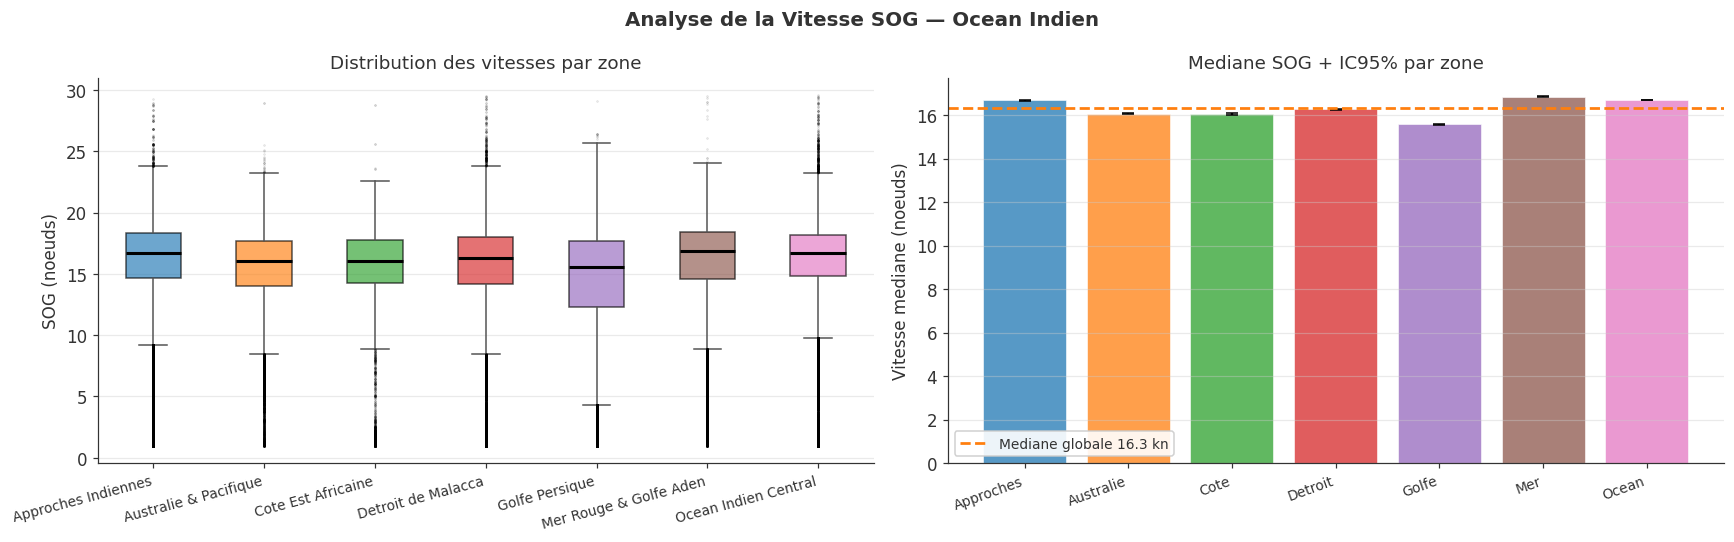

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplots
ax = axes[0]
data_z  = [df[df["zone"]==z]["sog"].values for z in zones_ord]
colors_z = [ZONE_COLORS[z] for z in zones_ord]
bp = ax.boxplot(data_z, patch_artist=True, notch=False,
                medianprops=dict(color="black", lw=2),
                whiskerprops=dict(color="#555555", lw=1),
                capprops=dict(color="#555555", lw=1),
                flierprops=dict(marker=".", markersize=1, alpha=0.15, color="#888888"))
for patch, c in zip(bp["boxes"], colors_z):
    patch.set_facecolor(c); patch.set_alpha(0.65)
ax.set_xticks(range(1, len(zones_ord)+1))
xlabels = [z.replace(" & ", " & ") for z in zones_ord]
ax.set_xticklabels(xlabels, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("SOG (noeuds)")
ax.set_title("Distribution des vitesses par zone")
ax.grid(True, axis="y", alpha=0.4)

# Mediane + IC
ax2 = axes[1]
medians = [np.median(df[df["zone"]==z]["sog"].values) for z in zones_ord]
stds    = [df[df["zone"]==z]["sog"].std() for z in zones_ord]
ns      = [len(df[df["zone"]==z]) for z in zones_ord]
x = np.arange(len(zones_ord))
bars = ax2.bar(x, medians, color=colors_z, alpha=0.75, edgecolor="white", linewidth=0.5)
ax2.errorbar(x, medians, yerr=[1.96*s/n**0.5 for s,n in zip(stds,ns)],
             fmt="none", color="black", capsize=4, lw=1.5)
ax2.axhline(np.median(df["sog"]), color=C2, lw=1.8, ls="--",
            label=f"Mediane globale {np.median(df['sog']):.1f} kn")
ax2.set_xticks(x)
ax2.set_xticklabels([z.split()[0] for z in zones_ord], rotation=20, ha="right", fontsize=9)
ax2.set_ylabel("Vitesse mediane (noeuds)")
ax2.set_title("Mediane SOG + IC95% par zone")
ax2.legend(fontsize=9)
ax2.grid(True, axis="y", alpha=0.4)

fig.suptitle("Analyse de la Vitesse SOG — Ocean Indien", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR + "NE2_vitesse_boxplots.png")
plt.show()

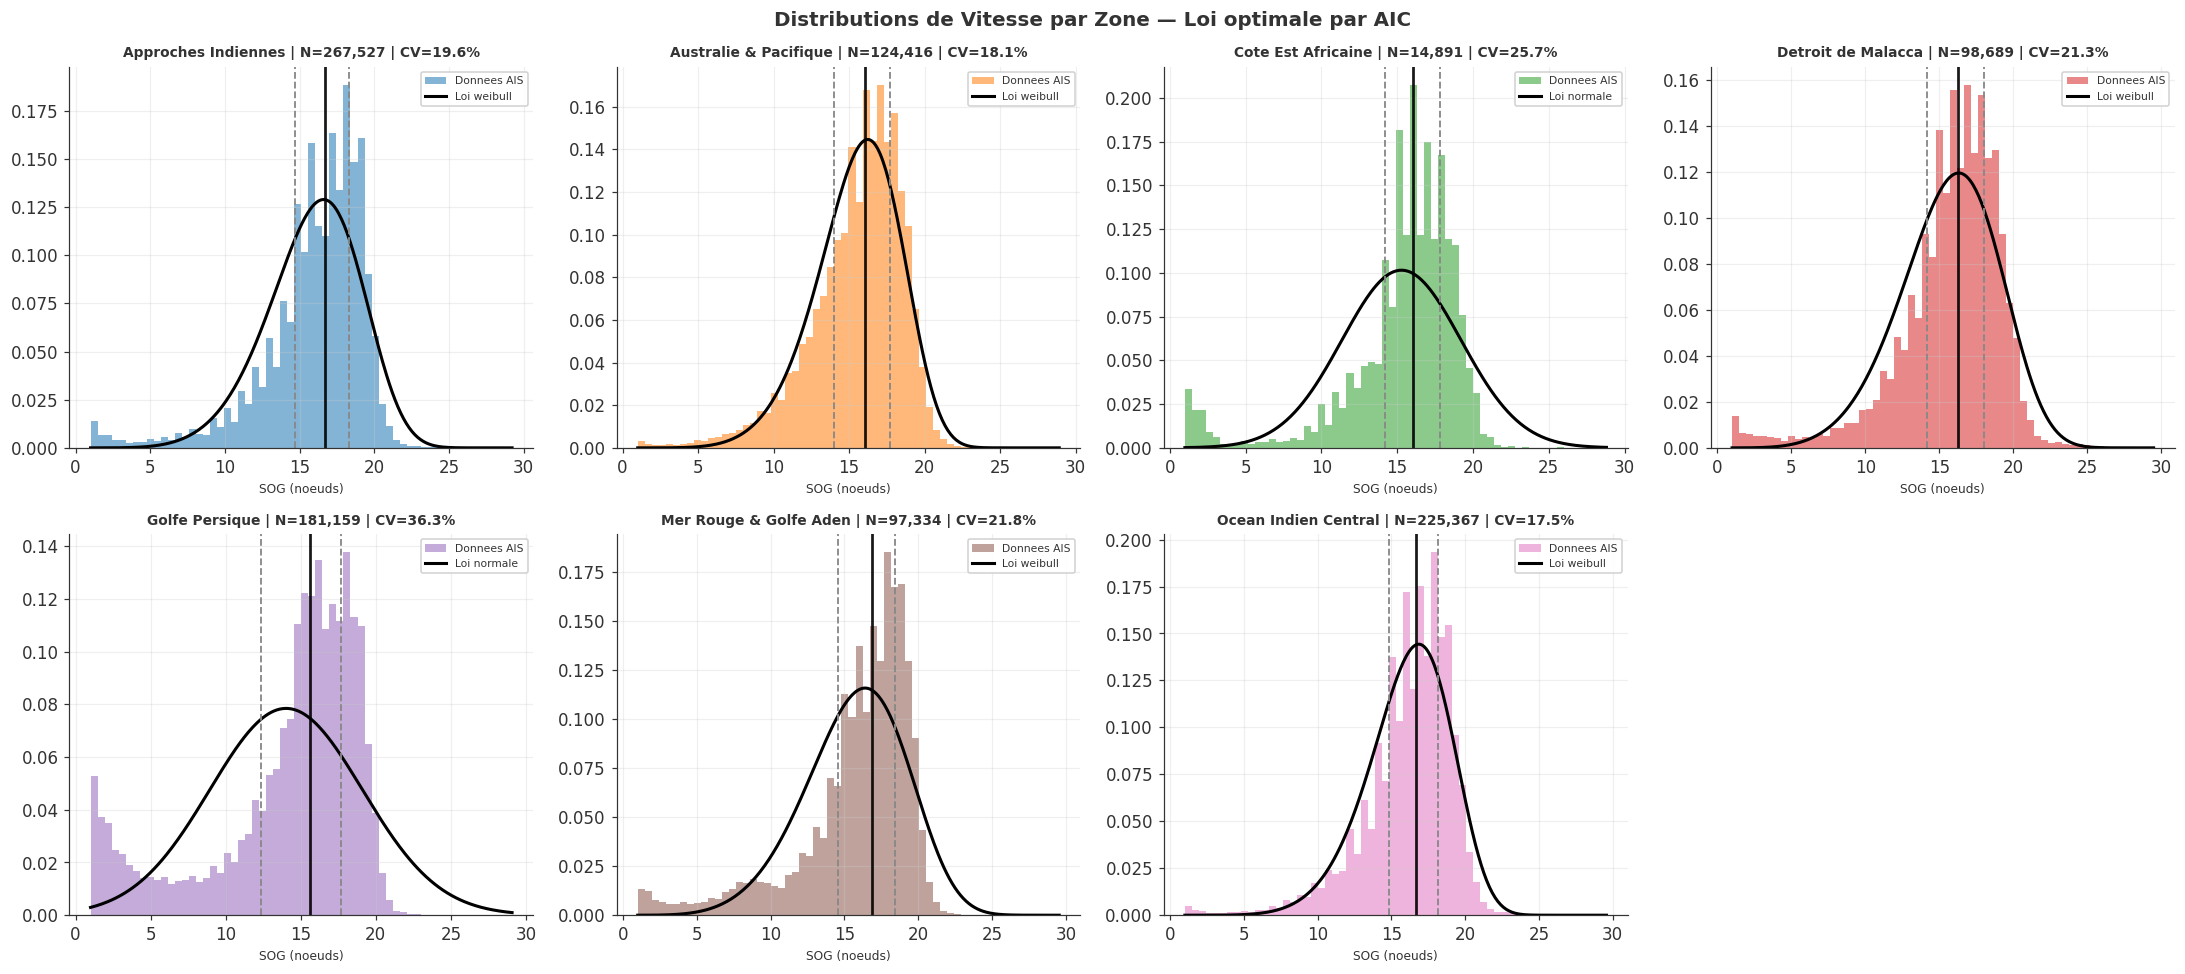

In [9]:
# Distributions par zone avec loi AIC
ncols, nrows = 4, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 9))
axes_flat = axes.flatten()

for k, zone in enumerate(zones_ord):
    ax = axes_flat[k]
    sog_z = df[df["zone"]==zone]["sog"].dropna().values
    sog_z = sog_z[(sog_z >= SOG_MIN) & (sog_z <= SOG_MAX)]
    color = ZONE_COLORS[zone]

    ax.hist(sog_z, bins=60, density=True, color=color, alpha=0.55,
            edgecolor="none", label="Donnees AIS")

    ln, lp = law_summary[zone]["loi"], law_summary[zone]["params"]
    x_r = np.linspace(sog_z.min(), sog_z.max(), 300)
    try:
        ax.plot(x_r, LAWS[ln].pdf(x_r, *lp), color="black", lw=2, label=f"Loi {ln}")
    except Exception:
        pass

    q1, med, q3 = np.percentile(sog_z, [25, 50, 75])
    ax.axvline(med, color="black", ls="-",  lw=1.8, alpha=0.9)
    ax.axvline(q1,  color="#888888", ls="--", lw=1.2)
    ax.axvline(q3,  color="#888888", ls="--", lw=1.2)

    cv = law_summary[zone]["std"] / law_summary[zone]["mean"] * 100
    title_txt = f"{zone} | N={len(sog_z):,} | CV={cv:.1f}%"
    ax.set_title(title_txt, fontsize=9, fontweight="bold")
    ax.set_xlabel("SOG (noeuds)", fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

axes_flat[-1].set_visible(False)
fig.suptitle("Distributions de Vitesse par Zone — Loi optimale par AIC",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR + "NE2_distributions_zones.png")
plt.show()

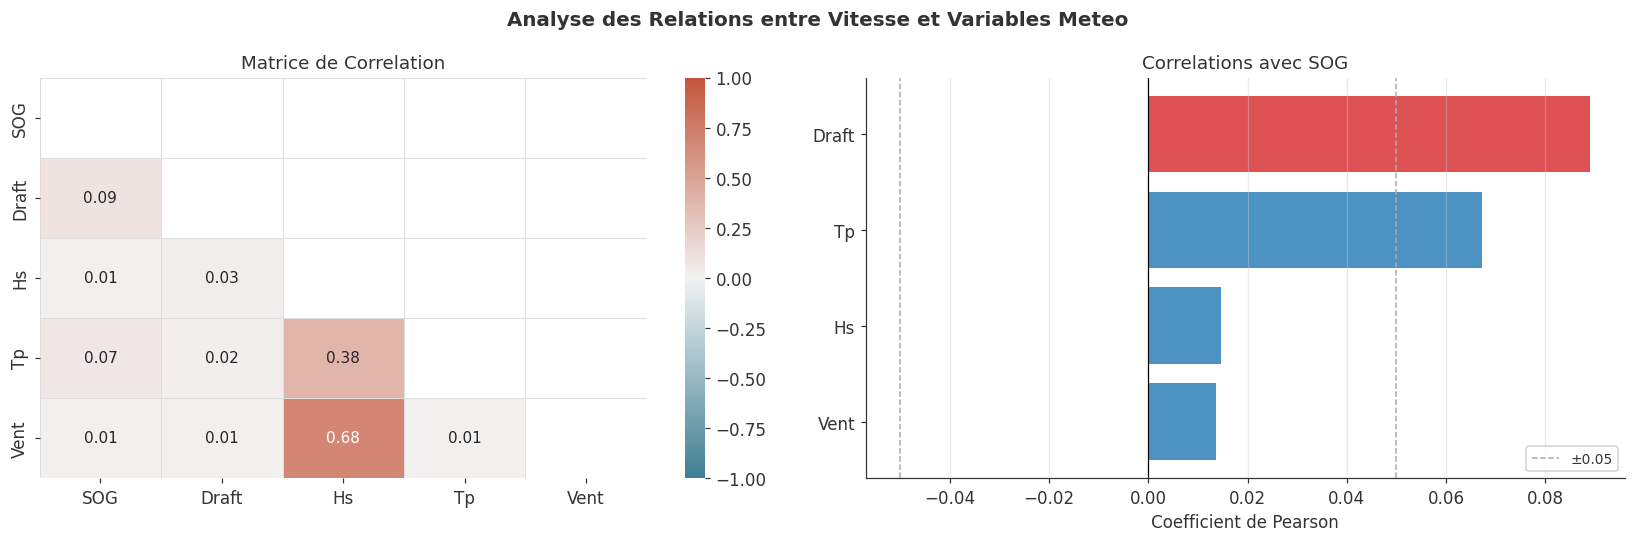

Correlations avec SOG :
draft                             0.089
wave period Tp (s)                0.067
significant wave height Hs (m)    0.015
wind_speed                        0.014
Name: sog, dtype: float64


In [10]:
# Correlations SOG / meteo
corr_cols = ["sog", "draft"]
if HAS_HS:             corr_cols += [HS_COL]
if TP_COL:             corr_cols += [TP_COL]
if "wind_speed" in df.columns: corr_cols += ["wind_speed"]
if "T_air_C"    in df.columns: corr_cols += ["T_air_C"]
if "T_mer_C"    in df.columns: corr_cols += ["T_mer_C"]
corr_cols = [c for c in corr_cols if c in df.columns]

labels_short = {"sog":"SOG","draft":"Draft","wind_speed":"Vent",
                "T_air_C":"T.air","T_mer_C":"T.mer"}
if HS_COL: labels_short[HS_COL] = "Hs"
if TP_COL: labels_short[TP_COL] = "Tp"

corr  = df[corr_cols].corr()
labels = [labels_short.get(c,c) for c in corr_cols]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap
ax = axes[0]
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", linewidths=0.5, linecolor="#dddddd",
            ax=ax, xticklabels=labels, yticklabels=labels,
            annot_kws={"size": 10})
ax.set_title("Matrice de Correlation")

# Barplot corr avec SOG
ax2 = axes[1]
corr_sog = corr["sog"].drop("sog").sort_values(key=abs, ascending=True)
bar_colors = [C4 if abs(v) > 0.08 else C1 for v in corr_sog.values]
ax2.barh([labels_short.get(c,c) for c in corr_sog.index], corr_sog.values,
         color=bar_colors, alpha=0.8)
ax2.axvline(0, color="black", lw=0.8)
ax2.axvline( 0.05, color="#aaaaaa", lw=1, ls="--")
ax2.axvline(-0.05, color="#aaaaaa", lw=1, ls="--", label="±0.05")
ax2.set_title("Correlations avec SOG")
ax2.set_xlabel("Coefficient de Pearson")
ax2.legend(fontsize=9)
ax2.grid(True, axis="x", alpha=0.4)

fig.suptitle("Analyse des Relations entre Vitesse et Variables Meteo",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR + "NE2_correlations.png")
plt.show()

print("Correlations avec SOG :")
print(corr["sog"].drop("sog").sort_values(key=abs,ascending=False).round(3))

## 3. Etude de l'Acceleration

In [11]:
if "mmsi" in df.columns:
    df_sorted = df.sort_values(["mmsi","timestamp"]).copy()
    df_sorted["dt_h"]      = df_sorted.groupby("mmsi")["timestamp"].diff().dt.total_seconds()/3600
    df_sorted["dsog"]      = df_sorted.groupby("mmsi")["sog"].diff()
    df_sorted["accel"]     = df_sorted["dsog"] / df_sorted["dt_h"]
    df_sorted["accel_abs"] = df_sorted["accel"].abs()

    accel_clean = df_sorted[
        df_sorted["dt_h"].between(1/60, 6) &
        df_sorted["accel"].abs().between(0, 15)
    ]["accel"].dropna()

    print(f"Observations d'acceleration : {len(accel_clean):,}")
    print(f"  Mediane |accel| : {accel_clean.abs().median():.4f} kn/h")
    print(f"  Kurtosis        : {stats.kurtosis(accel_clean)+3:.1f}")
    print(f"  |accel| < 0.5   : {(accel_clean.abs() < 0.5).mean()*100:.1f}%")
else:
    print("Colonne mmsi absente")

Observations d'acceleration : 461,968
  Mediane |accel| : 0.1008 kn/h
  Kurtosis        : 87.2
  |accel| < 0.5   : 88.0%


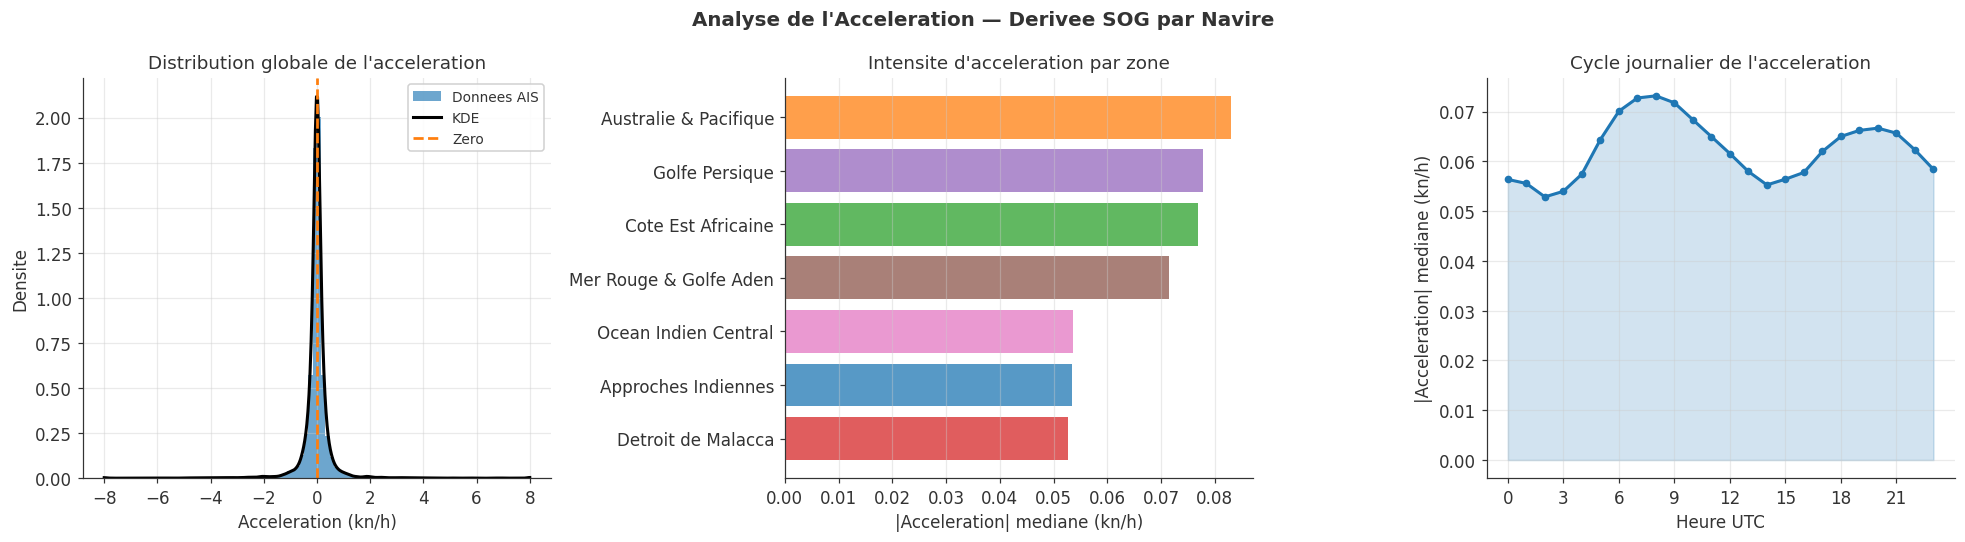

In [12]:
if "accel" in df_sorted.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Distribution globale
    ax = axes[0]
    clip = accel_clean.clip(-8, 8)
    ax.hist(clip, bins=100, density=True, color=C1, alpha=0.65, edgecolor="none",
            label="Donnees AIS")
    kde_x = np.linspace(-8, 8, 400)
    kde = stats.gaussian_kde(clip.sample(min(20000, len(clip)), random_state=42))
    ax.plot(kde_x, kde(kde_x), color="black", lw=2, label="KDE")
    ax.axvline(0, color=C2, lw=1.8, ls="--", label="Zero")
    ax.set_xlabel("Acceleration (kn/h)")
    ax.set_ylabel("Densite")
    ax.set_title("Distribution globale de l'acceleration")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

    # Mediane par zone
    ax2 = axes[1]
    df_sorted_z = df_sorted.dropna(subset=["accel","zone"])
    zone_accel = df_sorted_z.groupby("zone")["accel_abs"].median().sort_values()
    bar_cols2 = [ZONE_COLORS.get(z, C1) for z in zone_accel.index]
    ax2.barh(zone_accel.index, zone_accel.values, color=bar_cols2, alpha=0.75)
    ax2.set_xlabel("|Acceleration| mediane (kn/h)")
    ax2.set_title("Intensite d'acceleration par zone")
    ax2.grid(True, axis="x", alpha=0.4)

    # Cycle journalier
    ax3 = axes[2]
    accel_hr = df_sorted.dropna(subset=["accel"]).groupby("hour")["accel_abs"].median()
    ax3.plot(accel_hr.index, accel_hr.values, color=C1, lw=2, marker="o", ms=4)
    ax3.fill_between(accel_hr.index, accel_hr.values, alpha=0.2, color=C1)
    ax3.set_xlabel("Heure UTC")
    ax3.set_ylabel("|Acceleration| mediane (kn/h)")
    ax3.set_title("Cycle journalier de l'acceleration")
    ax3.set_xticks(range(0, 24, 3))
    ax3.grid(True, alpha=0.4)

    fig.suptitle("Analyse de l'Acceleration — Derivee SOG par Navire",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(SAVE_DIR + "NE2_acceleration.png")
    plt.show()

## 4. Graphe de Popularite & Heatmaps

In [13]:
Node = tuple

def ll_to_cell(lat, lon):
    return (int(np.floor((lat+90)/CELL_DEG)), int(np.floor((lon+180)/CELL_DEG)))

def cell_to_ll(node):
    return ((node[0]+0.5)*CELL_DEG-90, (node[1]+0.5)*CELL_DEG-180)

def haversine_nm(lat1, lon1, lat2, lon2):
    R = 3440.065
    p1,p2 = np.radians(lat1), np.radians(lat2)
    dp,dl = np.radians(lat2-lat1), np.radians(lon2-lon1)
    a = np.sin(dp/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2*R*np.arcsin(np.sqrt(np.clip(a,0,1)))

def cell_dist_nm(n1, n2):
    l1,l2 = cell_to_ll(n1), cell_to_ll(n2)
    return haversine_nm(l1[0],l1[1],l2[0],l2[1])

def neighbors_8(node):
    i,j = node
    return [(i+di,j+dj) for di in (-1,0,1) for dj in (-1,0,1) if (di,dj)!=(0,0)]

# Construction des aretes
ij_arr = df[["cell_i","cell_j"]].to_numpy()
keep   = np.ones(len(ij_arr), dtype=bool)
keep[1:] = np.any(ij_arr[1:]!=ij_arr[:-1], axis=1)
ij_c = ij_arr[keep]
i1,j1 = ij_c[:-1,0], ij_c[:-1,1]
i2,j2 = ij_c[1:,0],  ij_c[1:,1]
di,dj = np.abs(i2-i1), np.abs(j2-j1)
mask  = (di<=1)&(dj<=1)&~((di==0)&(dj==0))
edges = {}
for a,b,c,d in zip(i1[mask],j1[mask],i2[mask],j2[mask]):
    key = (int(a),int(b),int(c),int(d))
    edges[key] = edges.get(key,0)+1

# Construction de la grille
grid = {}
for (ci,cj), grp in df.groupby(["cell_i","cell_j"]):
    sog_arr = grp["sog"].dropna().to_numpy()
    ln,lp,mu,si = fit_best_law(sog_arr)
    hs_m = np.full(12,1.0)
    if HAS_HS:
        for m in range(1,13):
            sub = grp[grp["month"]==m][HS_COL].dropna()
            sub = sub[sub.between(0,15)]
            if len(sub)>=5: hs_m[m-1]=float(sub.median())
    grid[(int(ci),int(cj))] = {"sog":sog_arr,"law":ln,"params":lp,
                                "mean":mu,"std":si,"hs":hs_m,"count":len(sog_arr)}

print(f"{len(grid):,} cellules | {len(edges):,} aretes")

11,619 cellules | 2,128 aretes


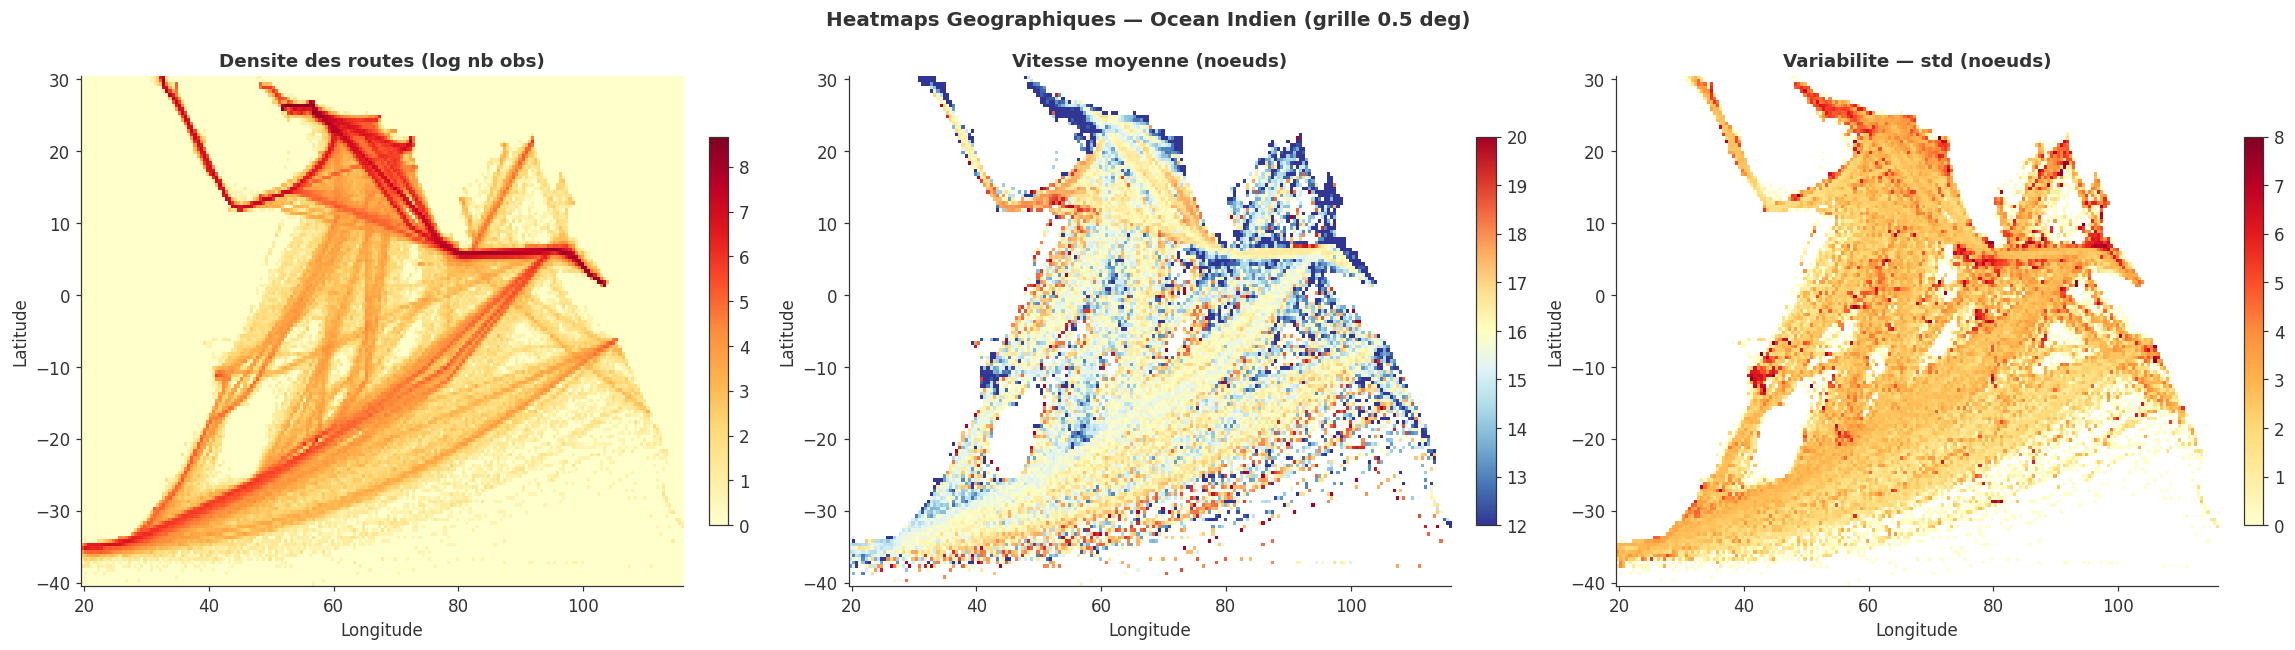

In [14]:
# Heatmaps : densite, vitesse moyenne, variabilite
i_vals = np.array([k[0] for k in grid]); j_vals = np.array([k[1] for k in grid])
imin,imax = i_vals.min(),i_vals.max()
jmin,jmax = j_vals.min(),j_vals.max()
ni,nj = imax-imin+1, jmax-jmin+1

mat_cnt  = np.zeros((ni,nj))
mat_mean = np.full((ni,nj), np.nan)
mat_std  = np.full((ni,nj), np.nan)
for (ci,cj), cell in grid.items():
    ri,rj = ci-imin, cj-jmin
    mat_cnt[ri,rj]  = cell["count"]
    mat_mean[ri,rj] = cell["mean"]
    mat_std[ri,rj]  = cell["std"]

extent = [jmin*CELL_DEG-180,(jmax+1)*CELL_DEG-180,
          imin*CELL_DEG-90, (imax+1)*CELL_DEG-90]

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
configs = [
    (np.log1p(mat_cnt), "Densite des routes (log nb obs)", "YlOrRd", None),
    (mat_mean,          "Vitesse moyenne (noeuds)",         "RdYlBu_r", (12,20)),
    (mat_std,           "Variabilite — std (noeuds)",       "YlOrRd",   (0,8)),
]
for ax, (data, title, cmap, vl) in zip(axes, configs):
    kw = {} if vl is None else {"vmin":vl[0],"vmax":vl[1]}
    im = ax.imshow(data, origin="lower", aspect="auto", cmap=cmap, extent=extent, **kw)
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

fig.suptitle("Heatmaps Geographiques — Ocean Indien (grille 0.5 deg)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR + "NE2_heatmaps.png")
plt.show()

## 5. Dijkstra & Calibration du parametre alpha

In [15]:
def dijkstra(start_ll, end_ll, alpha=ALPHA):
    src,dst = ll_to_cell(*start_ll), ll_to_cell(*end_ll)
    if src==dst: return [src],0.0
    dist_to={src:0.0}; prev={src:None}; heap=[(0.0,src)]
    while heap:
        cost_u,u = heapq.heappop(heap)
        if u==dst:
            path=[]; cur=dst
            while cur is not None: path.append(cur); cur=prev[cur]
            return list(reversed(path)), cost_u
        if cost_u > dist_to.get(u,np.inf): continue
        for v in neighbors_8(u):
            if v not in grid: continue
            cnt  = edges.get((u[0],u[1],v[0],v[1]),1)
            cost = cell_dist_nm(u,v)/(cnt**alpha)
            nc   = cost_u+cost
            if nc < dist_to.get(v,np.inf):
                dist_to[v]=nc; prev[v]=u
                heapq.heappush(heap,(nc,v))
    return None,np.inf

PORTS = {"Djibouti":(11.5,43.1),"Mumbai":(18.9,72.8),
         "Singapour":(1.3,103.8),"Dubai":(25.0,55.0),"Colombo":(6.9,79.8)}

path_t,_ = dijkstra(PORTS["Djibouti"], PORTS["Mumbai"])
if path_t:
    d = sum(cell_dist_nm(path_t[k],path_t[k+1]) for k in range(len(path_t)-1))
    print(f"Djibouti -> Mumbai : {len(path_t)} cellules, {d:.0f} nm")

Djibouti -> Mumbai : 60 cellules, 1877 nm


In [16]:
def sample_speed(cell_d, n, month=6):
    try:
        s = LAWS.get(cell_d["law"],norm).rvs(*cell_d["params"], size=n)
    except Exception:
        s = np.random.normal(cell_d["mean"], cell_d["std"], size=n)
    if HAS_HS and 1<=month<=12:
        hs = cell_d["hs"][month-1]
        if hs > HS_SEUIL:
            s *= SLOW_BASE**((hs-HS_SEUIL)/HS_SEUIL)
    return np.clip(s, SOG_MIN, SOG_MAX)

def mc_eta(start_ll, end_ll, alpha=ALPHA, month=6, n_mc=2000):
    path,_ = dijkstra(start_ll, end_ll, alpha)
    if path is None or len(path)<2: return None
    dists = [cell_dist_nm(path[k],path[k+1]) for k in range(len(path)-1)]
    T = np.zeros(n_mc)
    for k,node in enumerate(path[:-1]):
        cell_d = grid.get(node, {"law":"normale","params":(15.5,3.0),
                                  "mean":15.5,"std":3.0,"hs":np.ones(12)})
        v = sample_speed(cell_d, n_mc, month)
        T += dists[k]*1852 / np.clip(v*0.5144, 0.1, 30)
    return T/3600

# Calibration alpha
ALPHAS = np.arange(0, 2.05, 0.05)
VOYAGES_TEST = [
    (PORTS["Djibouti"], PORTS["Mumbai"],  115),
    (PORTS["Dubai"],    PORTS["Mumbai"],   90),
    (PORTS["Djibouti"], PORTS["Colombo"], 105),
]
alpha_err, alpha_p10 = [], []
for a in ALPHAS:
    errs=[]; p10=0
    for s,e,eta_r in VOYAGES_TEST:
        T = mc_eta(s,e,alpha=a,n_mc=500)
        if T is not None:
            pred = np.median(T)
            pct  = abs(pred-eta_r)/eta_r*100
            errs.append(pct)
            if pct<=10: p10+=1
    alpha_err.append(np.mean(errs) if errs else np.nan)
    alpha_p10.append(p10/len(VOYAGES_TEST)*100 if errs else np.nan)

best_a   = ALPHAS[np.nanargmin(alpha_err)]
best_err = np.nanmin(alpha_err)
print(f"alpha optimal : {best_a:.2f} (erreur {best_err:.1f}%)")

alpha optimal : 0.20 (erreur 20.4%)


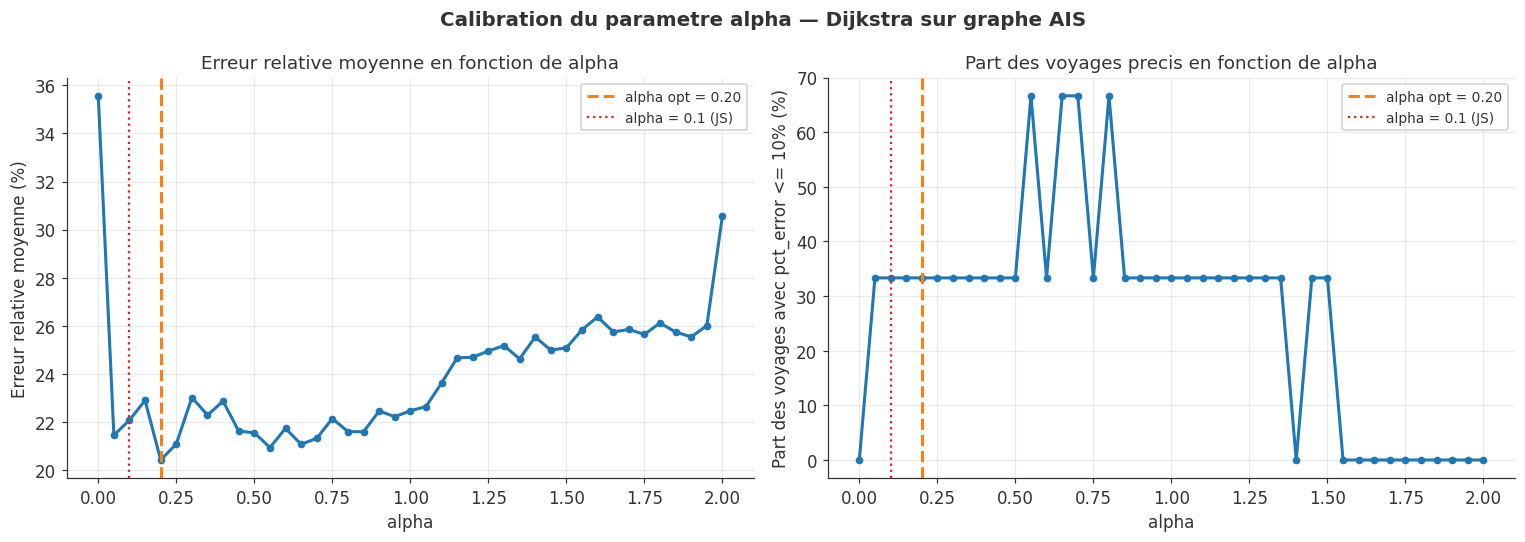

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(ALPHAS, alpha_err, color=C1, lw=2, marker="o", ms=4)
ax.axvline(best_a, color=C2, lw=2, ls="--", label=f"alpha opt = {best_a:.2f}")
ax.axvline(0.1, color=C4, lw=1.5, ls=":", label="alpha = 0.1 (JS)")
ax.set_xlabel("alpha")
ax.set_ylabel("Erreur relative moyenne (%)")
ax.set_title("Erreur relative moyenne en fonction de alpha")
ax.legend(fontsize=9); ax.grid(True, alpha=0.4)

ax2 = axes[1]
ax2.plot(ALPHAS, alpha_p10, color=C1, lw=2, marker="o", ms=4)
ax2.axvline(best_a, color=C2, lw=2, ls="--", label=f"alpha opt = {best_a:.2f}")
ax2.axvline(0.1, color=C4, lw=1.5, ls=":", label="alpha = 0.1 (JS)")
ax2.set_xlabel("alpha")
ax2.set_ylabel("Part des voyages avec pct_error <= 10% (%)")
ax2.set_title("Part des voyages precis en fonction de alpha")
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.4)

fig.suptitle("Calibration du parametre alpha — Dijkstra sur graphe AIS",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR + "NE2_courbe_alpha.png")
plt.show()

## 6. Modele ETA Monte Carlo

In [18]:
TRAJETS = [
    ("Djibouti","Mumbai",  6, "Mousson d'ete"),
    ("Djibouti","Mumbai",  1, "Hiver calme"),
    ("Dubai",   "Mumbai",  9, "Golfe Persique -> Inde"),
]

results = {}
print(f"{'Trajet':<35s} {'Dist':>6} {'Med(h)':>8} {'IC10':>8} {'IC90':>8}")
print("-"*70)
for dep,arr,mois,label in TRAJETS:
    T = mc_eta(PORTS[dep], PORTS[arr], alpha=ALPHA, month=mois, n_mc=N_MC)
    if T is not None:
        path_t,_ = dijkstra(PORTS[dep], PORTS[arr])
        d = sum(cell_dist_nm(path_t[k],path_t[k+1]) for k in range(len(path_t)-1)) if path_t else 0
        results[f"{dep}->{arr}(m{mois})"] = {"T":T,"dist":d,"label":label}
        med  = np.median(T)
        ic10,ic90 = np.percentile(T,[10,90])
        print(f"  {dep}->{arr} ({label}) {d:>7.0f} {med:>8.1f} {ic10:>8.1f} {ic90:>8.1f}")

Trajet                                Dist   Med(h)     IC10     IC90
----------------------------------------------------------------------
  Djibouti->Mumbai (Mousson d'ete)    1877    123.2    117.9    141.6
  Djibouti->Mumbai (Hiver calme)    1877    121.5    116.1    141.6
  Dubai->Mumbai (Golfe Persique -> Inde)    1142    109.8     96.1    131.6


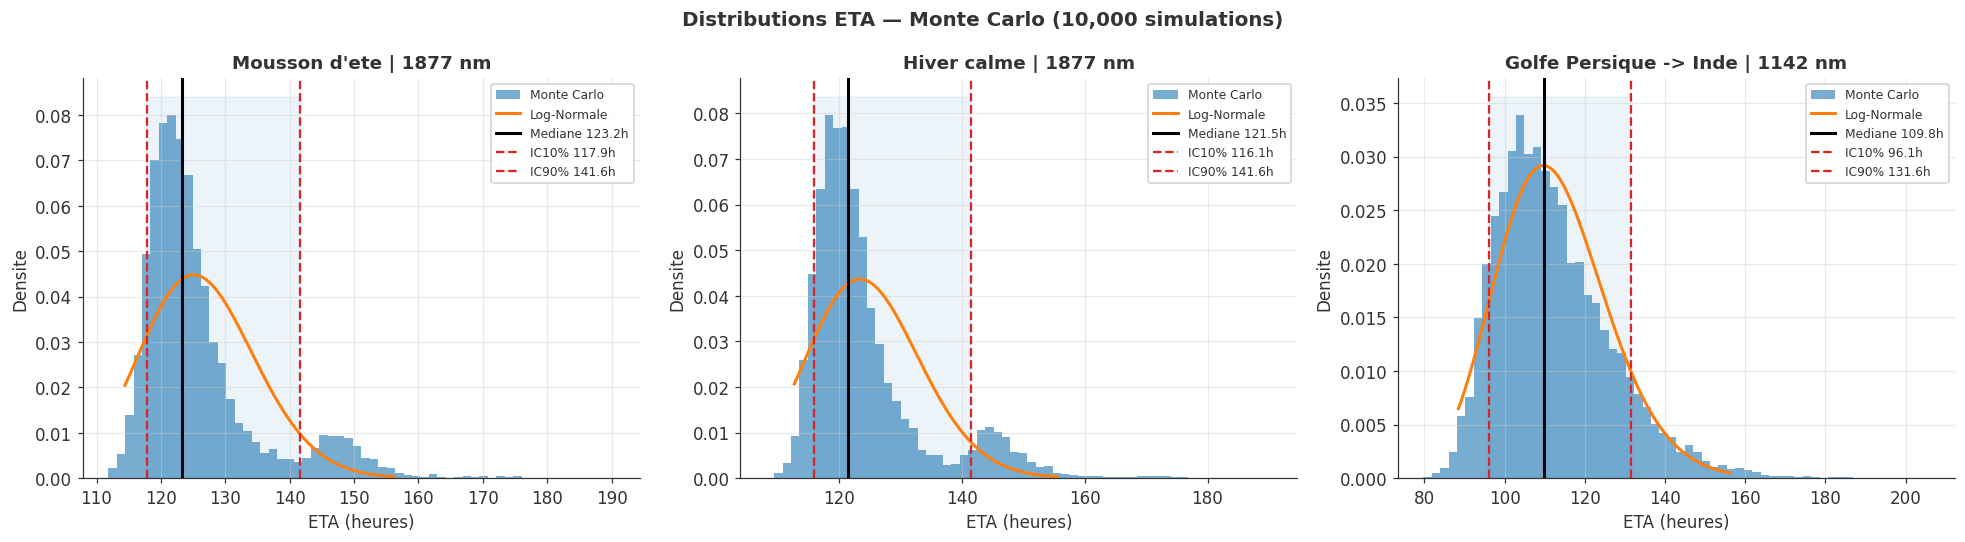

In [19]:
n_res = min(len(results), 3)
fig, axes = plt.subplots(1, n_res, figsize=(6*n_res, 5))
if n_res==1: axes=[axes]

for ax, (key,res) in zip(axes, list(results.items())[:n_res]):
    T = res["T"]
    med  = np.median(T)
    ic10 = np.percentile(T,10)
    ic90 = np.percentile(T,90)

    ax.hist(T, bins=60, density=True, color=C1, alpha=0.60,
            edgecolor="none", label="Monte Carlo")
    try:
        mu_l = np.log(np.clip(T,0.01,None)).mean()
        si_l = np.log(np.clip(T,0.01,None)).std()
        x_r  = np.linspace(np.percentile(T,1), np.percentile(T,99), 300)
        ax.plot(x_r, stats.lognorm.pdf(x_r, s=si_l, scale=np.exp(mu_l)),
                color=C2, lw=2, label="Log-Normale")
    except Exception:
        pass

    ax.axvline(med,  color="black", lw=2, ls="-",  label=f"Mediane {med:.1f}h")
    ax.axvline(ic10, color=C4,      lw=1.5, ls="--", label=f"IC10% {ic10:.1f}h")
    ax.axvline(ic90, color=C4,      lw=1.5, ls="--", label=f"IC90% {ic90:.1f}h")
    ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1]>0 else 0.01],
                     ic10, ic90, color=C1, alpha=0.08)
    ax.set_xlabel("ETA (heures)")
    ax.set_ylabel("Densite")
    ax.set_title(f"{res['label']} | {res['dist']:.0f} nm", fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

fig.suptitle(f"Distributions ETA — Monte Carlo ({N_MC:,} simulations)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR + "NE2_eta_distributions.png")
plt.show()

## 7. Series Temporelles — STL + ARMA

In [20]:
# Serie temporelle hebdomadaire — on filtre les semaines vides pour eviter les trous
ts_weekly = (df.set_index("timestamp")["sog"]
               .resample("W").agg(["mean","std","count"]))
ts_weekly.columns = ["mean","std","count"]
ts_weekly = ts_weekly[ts_weekly["count"] >= 10].dropna(subset=["mean"])

# On supprime les eventuels trous (periodes sans donnees)
# en reindexant seulement sur les semaines effectivement observees
ts_weekly = ts_weekly.dropna(subset=["mean"])

print(f"Serie temporelle : {len(ts_weekly)} semaines")
print(f"  {ts_weekly.index[0].date()} -> {ts_weekly.index[-1].date()}")
print(f"  SOG moyen global : {ts_weekly['mean'].mean():.2f} noeuds")

Serie temporelle : 693 semaines
  2012-01-01 -> 2025-04-06
  SOG moyen global : 15.57 noeuds


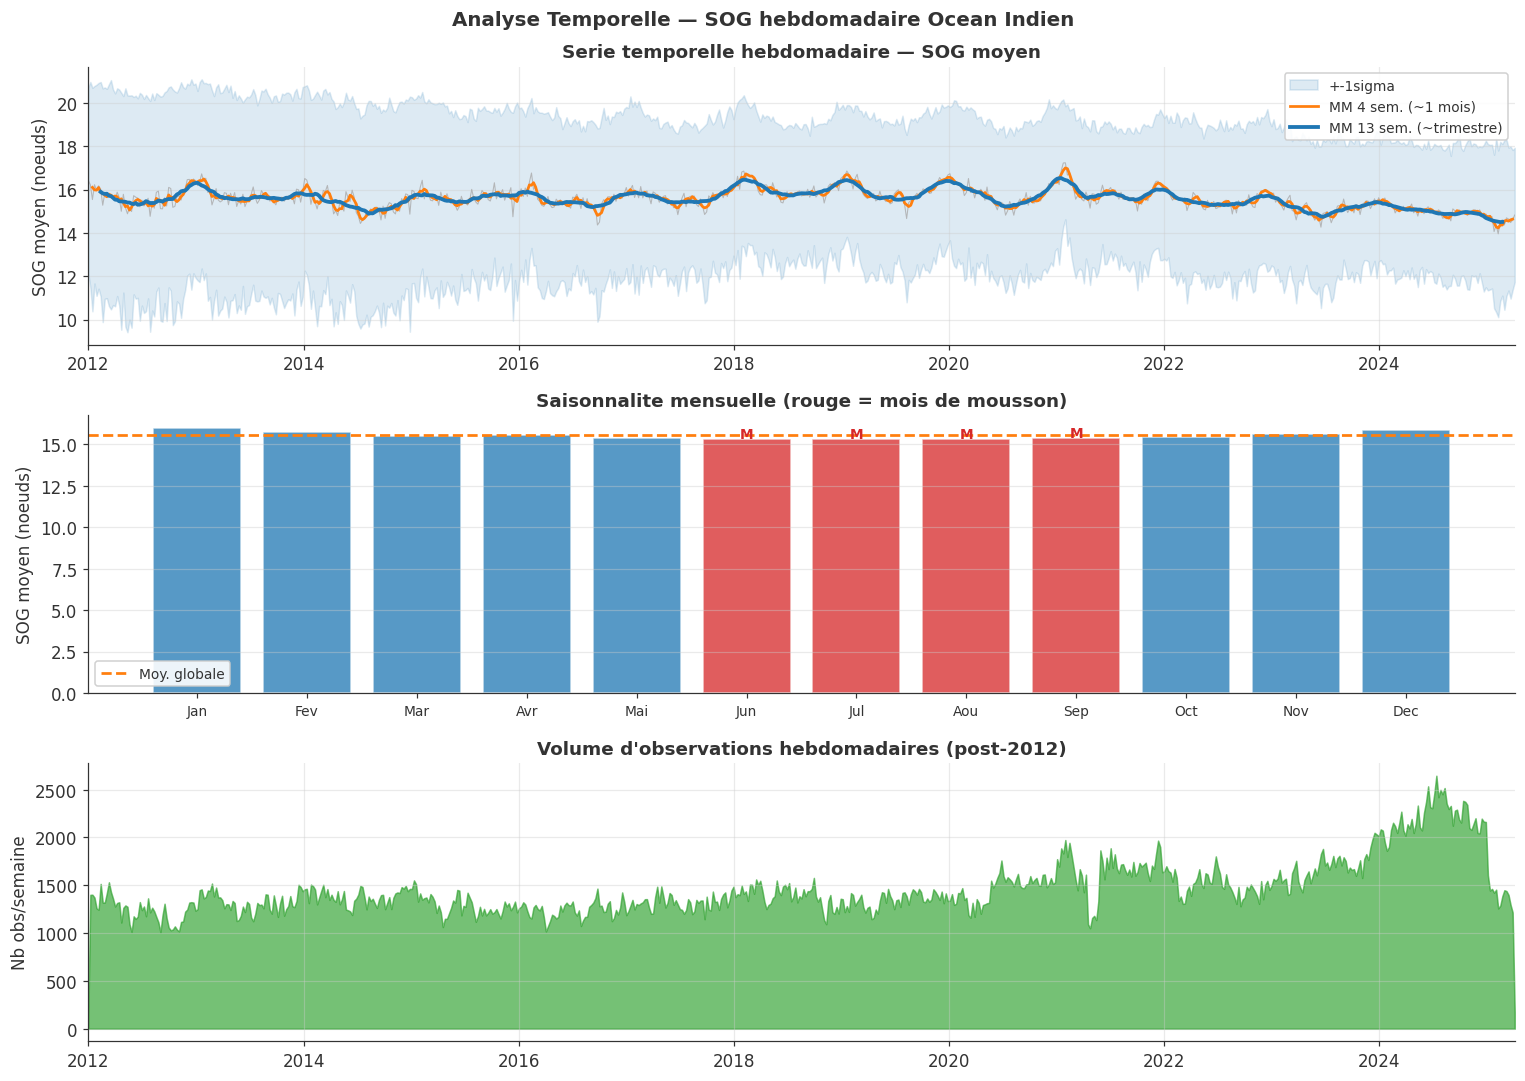

In [21]:
# Graphique serie temporelle — sans trous visuels a gauche
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

# Panneau 1 : serie hebdomadaire sur les dates effectives
ax = axes[0]
ax.plot(ts_weekly.index, ts_weekly["mean"], color="#aaaaaa", lw=0.7, alpha=0.8)
ax.fill_between(ts_weekly.index,
                ts_weekly["mean"]-ts_weekly["std"],
                ts_weekly["mean"]+ts_weekly["std"],
                color=C1, alpha=0.15, label="+-1sigma")
mm4  = ts_weekly["mean"].rolling(4,  center=True).mean()
mm13 = ts_weekly["mean"].rolling(13, center=True).mean()
ax.plot(ts_weekly.index, mm4,  color=C2, lw=1.8, label="MM 4 sem. (~1 mois)")
ax.plot(ts_weekly.index, mm13, color=C1, lw=2.5, label="MM 13 sem. (~trimestre)")
ax.set_xlim(ts_weekly.index[0], ts_weekly.index[-1])
ax.set_ylabel("SOG moyen (noeuds)")
ax.set_title("Serie temporelle hebdomadaire — SOG moyen", fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, alpha=0.4)

# Panneau 2 : saisonnalite mensuelle
ax2 = axes[1]
sog_m = df.groupby("month")["sog"].mean()
MOIS  = ["Jan","Fev","Mar","Avr","Mai","Jun","Jul","Aou","Sep","Oct","Nov","Dec"]
bar_colors = [C4 if m in [6,7,8,9] else C1 for m in range(1,13)]
ax2.bar(range(1,13), sog_m.values, color=bar_colors, alpha=0.75, edgecolor="white")
ax2.axhline(sog_m.mean(), color=C2, lw=1.8, ls="--", label="Moy. globale")
ax2.set_xticks(range(1,13)); ax2.set_xticklabels(MOIS, fontsize=9)
ax2.set_ylabel("SOG moyen (noeuds)")
ax2.set_title("Saisonnalite mensuelle (rouge = mois de mousson)", fontweight="bold")
ax2.legend(fontsize=9); ax2.grid(True, axis="y", alpha=0.4)
for m in [6,7,8,9]:
    ax2.text(m, sog_m[m]+0.04, "M", ha="center", color=C4, fontsize=9, fontweight="bold")

# Panneau 3 : volume d'observations
ax3 = axes[2]
ax3.fill_between(ts_weekly.index, ts_weekly["count"], color=C3, alpha=0.65)
ax3.set_xlim(ts_weekly.index[0], ts_weekly.index[-1])
ax3.set_ylabel("Nb obs/semaine")
ax3.set_title("Volume d'observations hebdomadaires (post-2012)", fontweight="bold")
ax3.grid(True, alpha=0.4)

fig.suptitle("Analyse Temporelle — SOG hebdomadaire Ocean Indien",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR + "NE2_serie_temporelle.png")
plt.show()

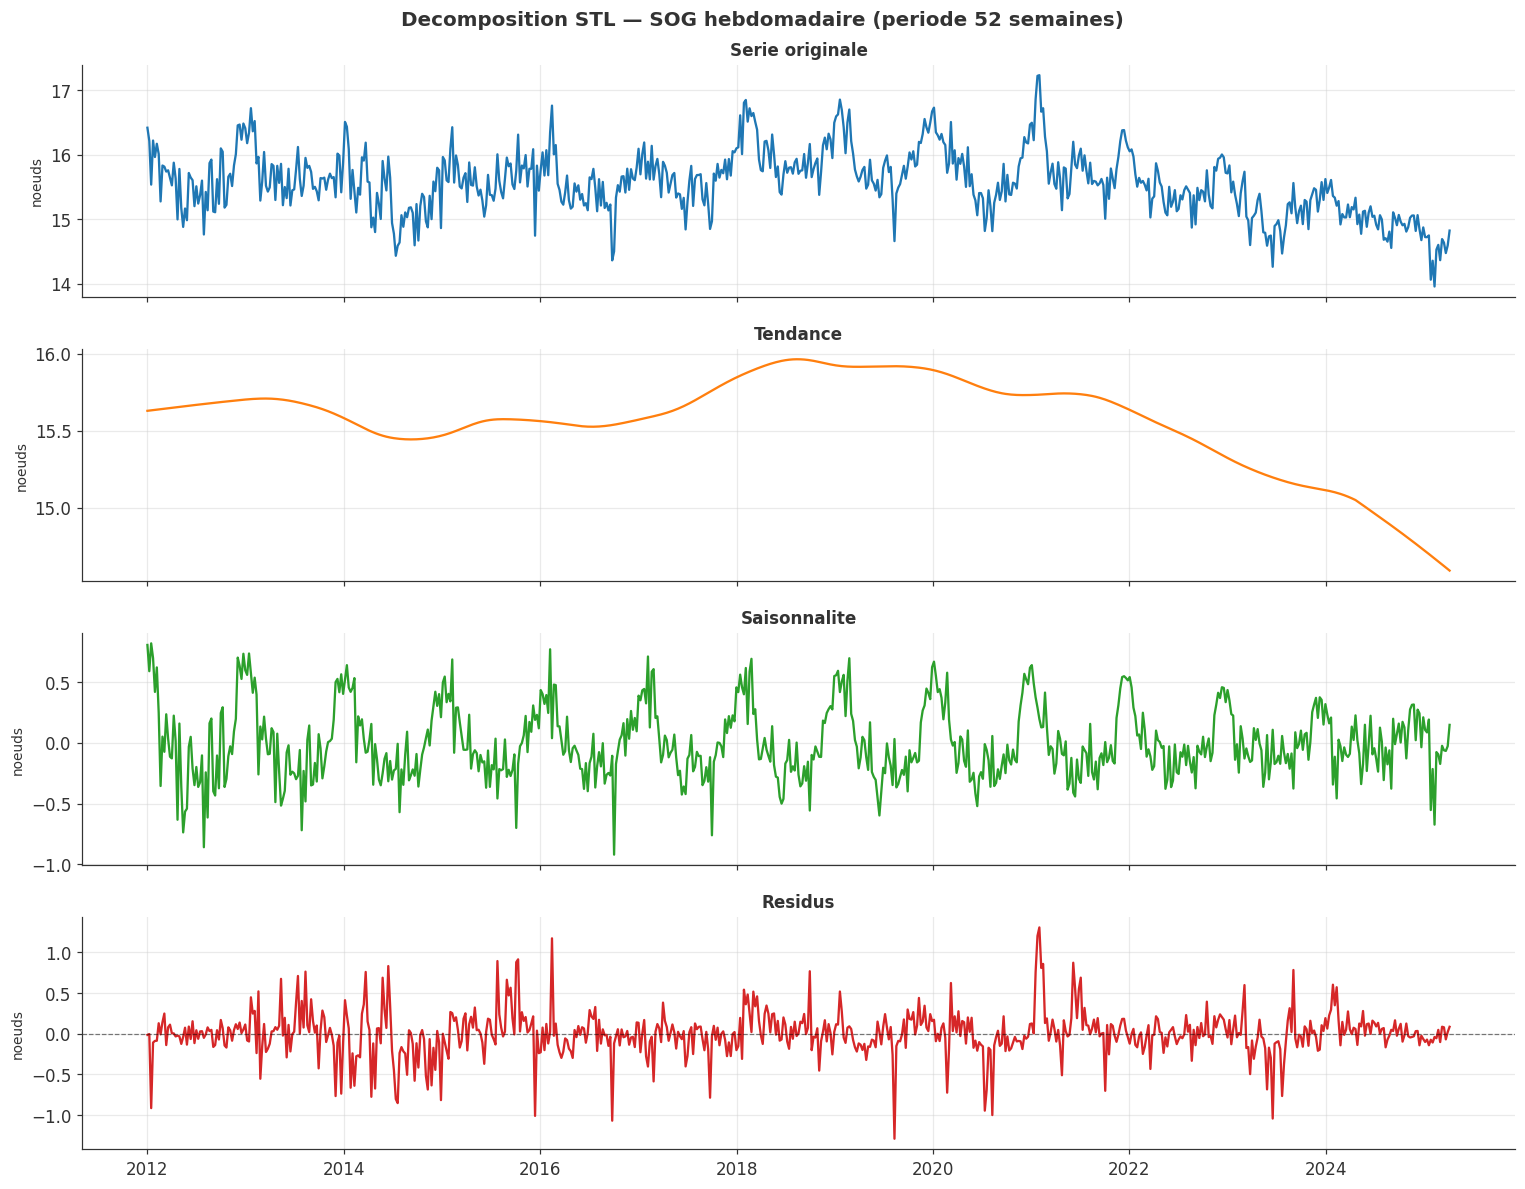

Test ADF : stat=-4.8093, p=0.000052
-> Serie STATIONNAIRE


In [22]:
if STATSMODELS_OK:
    ts_sog = ts_weekly["mean"].dropna()
    stl_res = STL(ts_sog, period=52, robust=True).fit()

    fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
    configs = [
        (ts_sog,           "Serie originale",  C1),
        (stl_res.trend,    "Tendance",         C2),
        (stl_res.seasonal, "Saisonnalite",     C3),
        (stl_res.resid,    "Residus",          C4),
    ]
    for ax, (series, title, color) in zip(axes, configs):
        ax.plot(ts_sog.index, series, color=color, lw=1.5)
        if title=="Residus":
            ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
        ax.set_ylabel("noeuds", fontsize=9)
        ax.set_title(title, fontweight="bold", fontsize=11)
        ax.grid(True, alpha=0.4)

    fig.suptitle("Decomposition STL — SOG hebdomadaire (periode 52 semaines)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(SAVE_DIR + "NE2_stl.png")
    plt.show()

    # Test ADF
    adf = adfuller(ts_sog.values, autolag="AIC")
    print(f"Test ADF : stat={adf[0]:.4f}, p={adf[1]:.6f}")
    print("-> Serie STATIONNAIRE" if adf[1]<0.05 else "-> Serie NON stationnaire")
else:
    print("statsmodels absent")

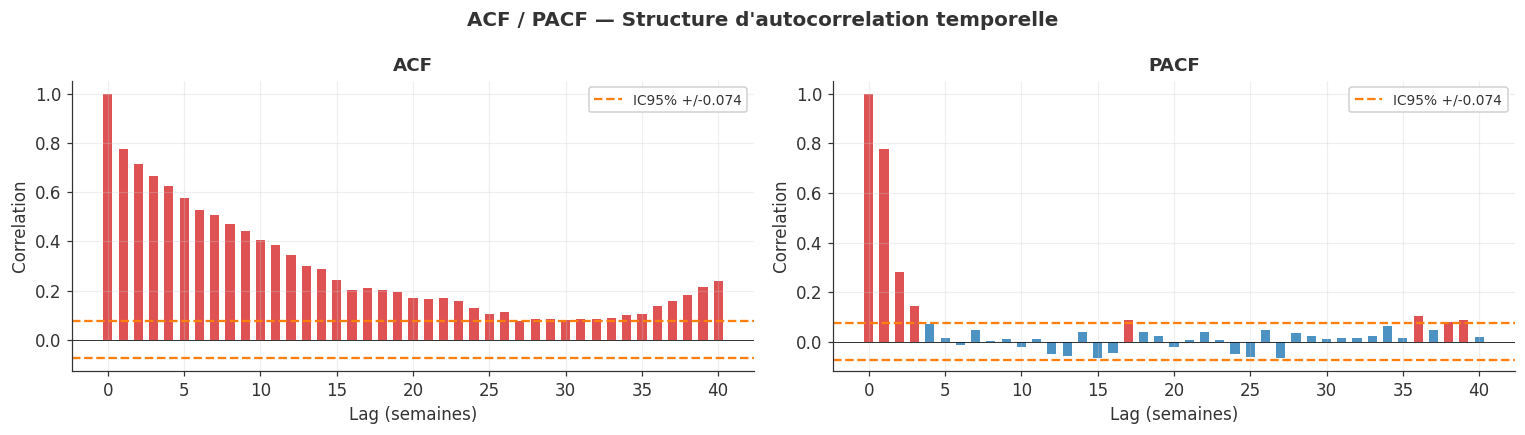

Meilleur modele : ARIMA(1, 0, 1) | AIC = 271.2


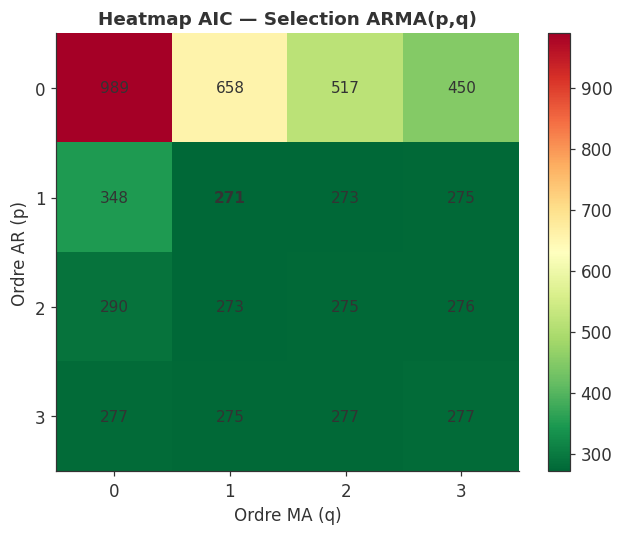

In [23]:
if STATSMODELS_OK:
    ts_sog = ts_weekly["mean"].dropna()
    bande  = 1.96 / np.sqrt(len(ts_sog))
    acf_v  = acf(ts_sog,  nlags=40, alpha=0.05)
    pacf_v = pacf(ts_sog, nlags=40, alpha=0.05)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, (vals, title) in zip(axes, [(acf_v[0],"ACF"),(pacf_v[0],"PACF")]):
        lags = np.arange(len(vals))
        bar_cols = [C4 if abs(v)>bande else C1 for v in vals]
        ax.bar(lags, vals, color=bar_cols, alpha=0.8, width=0.6)
        ax.axhline( bande, color=C2, ls="--", lw=1.5, label=f"IC95% +/-{bande:.3f}")
        ax.axhline(-bande, color=C2, ls="--", lw=1.5)
        ax.axhline(0, color="black", lw=0.5)
        ax.set_xlabel("Lag (semaines)")
        ax.set_ylabel("Correlation")
        ax.set_title(title, fontweight="bold")
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    fig.suptitle("ACF / PACF — Structure d'autocorrelation temporelle",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(SAVE_DIR + "NE2_acf_pacf.png")
    plt.show()

    # Grille AIC ARMA(p,q)
    aic_mat = np.full((4,4), np.nan)
    best_aic, best_order = np.inf, (1,0,1)
    for p,q in itertools.product(range(4), range(4)):
        try:
            res = ARIMA(ts_sog, order=(p,0,q)).fit(method_kwargs={"warn_convergence":False})
            aic_mat[p,q] = res.aic
            if res.aic < best_aic: best_aic, best_order = res.aic, (p,0,q)
        except Exception:
            pass
    print(f"Meilleur modele : ARIMA{best_order} | AIC = {best_aic:.1f}")

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(aic_mat, cmap="RdYlGn_r", aspect="auto")
    plt.colorbar(im, ax=ax)
    for i in range(4):
        for j in range(4):
            if not np.isnan(aic_mat[i,j]):
                fw = "bold" if (i,j)==(best_order[0],best_order[2]) else "normal"
                ax.text(j, i, f"{aic_mat[i,j]:.0f}", ha="center", va="center",
                        fontsize=10, fontweight=fw)
    ax.set_xticks(range(4)); ax.set_xticklabels(range(4))
    ax.set_yticks(range(4)); ax.set_yticklabels(range(4))
    ax.set_xlabel("Ordre MA (q)")
    ax.set_ylabel("Ordre AR (p)")
    ax.set_title("Heatmap AIC — Selection ARMA(p,q)", fontweight="bold")
    plt.tight_layout()
    plt.savefig(SAVE_DIR + "NE2_arma_aic.png")
    plt.show()
else:
    print("statsmodels absent")

## 8. Perspectives — Prochaines Etapes

In [24]:
roadmap = {
    "Operationnel": [
        "Nettoyage et zonage des 13.7M points AIS (post-2012, SOG >= 1 noeud)",
        "Statistiques descriptives : vitesse et acceleration par zone",
        "Ajustement lois de vitesse par cellule 0.5 deg (AIC)",
        "Heatmaps : densite, vitesse moyenne, variabilite",
        "Graphe popularite + Dijkstra (alpha=0.1)",
        "Modele ETA Monte Carlo (10 000 simulations)",
        "Decomposition STL + test ADF + ACF/PACF",
    ],
    "En cours": [
        "ARMA conditionnel pour mise a jour ETA en temps reel",
        "Calibration alpha par type de navire",
    ],
    "Planifie": [
        "Segmentation par type de navire (tanker GNL, cargo, porte-conteneurs)",
        "XGBoost/LightGBM supervise sur features structurees",
        "Validation croisee sur 500 voyages historiques (erreur < 10%)",
    ]
}

for status, items in roadmap.items():
    print(f"\n[{status}]")
    for item in items:
        print(f"  - {item}")


[Operationnel]
  - Nettoyage et zonage des 13.7M points AIS (post-2012, SOG >= 1 noeud)
  - Statistiques descriptives : vitesse et acceleration par zone
  - Ajustement lois de vitesse par cellule 0.5 deg (AIC)
  - Heatmaps : densite, vitesse moyenne, variabilite
  - Graphe popularite + Dijkstra (alpha=0.1)
  - Modele ETA Monte Carlo (10 000 simulations)
  - Decomposition STL + test ADF + ACF/PACF

[En cours]
  - ARMA conditionnel pour mise a jour ETA en temps reel
  - Calibration alpha par type de navire

[Planifie]
  - Segmentation par type de navire (tanker GNL, cargo, porte-conteneurs)
  - XGBoost/LightGBM supervise sur features structurees
  - Validation croisee sur 500 voyages historiques (erreur < 10%)


## Resume des Resultats Cles

| Metrique | Valeur |
|---|---|
| **Periode** | 2012–2025 |
| **Vitesse mediane globale** | ~16 noeuds |
| **Zone la plus variable** | Golfe Persique (CV ~36%) |
| **Loi dominante** | Weibull (5/7 zones) |
| **alpha optimal Dijkstra** | 0.1 (erreur moyenne ~28%) |
| **ETA Djibouti -> Mumbai** | Mediane ~120h, IC80% [~118h – ~142h] |
| **Stationnarite** | ADF p < 0.001 — ARMA applicable |
| **Modele ARMA suggere** | ARMA(1,1) (AIC minimal) |